# Project 1

# Step 1: Load the Dataset and Understand the Dataset

In [15]:
import pandas as pd

# load excel file
df = pd.read_excel("Dataset for Data Analytics.xlsx")

# view first 5 rows
print(df.head())
print()
# rows and columns
print(df.shape)
print()
# column names
print(df.columns)
print()
# data types
print(df.dtypes)
print()
# basic information
print(df.info())
print()

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

# Step 2: Find Missing Values

In [16]:
# Count missing values in each column
print(df.isnull().sum())
print()
# Show columns that have missing values
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
# Total missing values in dataset
print("Total Missing Values:", df.isnull().sum().sum())
print()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

CouponCode    309
dtype: int64

Total Missing Values: 309



# Step 3: Analyze the Missing Values

In [17]:
# View unique coupon codes
print(df['CouponCode'].unique())
print()
# Frequency of coupon codes
print(df['CouponCode'].value_counts())
print()
# Missing value percentage
missing_pct = (df['CouponCode'].isnull().sum() / len(df)) * 100
print("Missing Percentage:", round(missing_pct, 2), "%")
print()

['SAVE10' 'FREESHIP' nan 'WINTER15']

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

Missing Percentage: 25.75 %



# Step 4: Handle Missing CouponCode Values

In [18]:
# Missing values before filling
print(df['CouponCode'].isnull().sum())
print()
# Replace missing coupon codes with 'No Coupon'
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
# Missing values after filling
print(df['CouponCode'].isnull().sum())
print()
# Check updated counts
print(df['CouponCode'].value_counts())

309

0

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


# Step 5: Check for Duplicate Records

In [19]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
print()
# Show duplicate rows
print(df[df.duplicated()])
print()
# Count duplicate Order IDs
print("Duplicate Order IDs:", df['OrderID'].duplicated().sum())
print()
# Display duplicate Order IDs
print(df[df['OrderID'].duplicated(keep=False)].sort_values('OrderID'))

Duplicate Rows: 0

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice]
Index: []

Duplicate Order IDs: 0

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice]
Index: []


# Step 6: Check Date Format Consistency

In [20]:
# Verify date datatype
print(df['Date'].dtype)
print()
# Count missing dates
print("Missing Dates:", df['Date'].isnull().sum())
print()
# View sample dates
print(df['Date'].head())
print()
# Validate date conversion
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Check invalid dates
print("Invalid Dates:", df['Date'].isnull().sum())
print()

datetime64[ns]

Missing Dates: 0

0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[ns]

Invalid Dates: 0



# Step 7: Check Text Columns for Formatting Issues

In [21]:
# Show object columns
print(df.select_dtypes(include='object').columns)
print()
# Product values
print(df['Product'].unique())

# Payment methods
print(df['PaymentMethod'].unique())

# Order status
print(df['OrderStatus'].unique())

# Referral source
print(df['ReferralSource'].unique())
print()
# Count rows with leading/trailing spaces
for col in df.select_dtypes(include='object').columns:
    count = (df[col] != df[col].str.strip()).sum()
    print(col, ":", count)

Index(['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod',
       'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource'],
      dtype='object')

['Monitor' 'Phone' 'Tablet' 'Chair' 'Printer' 'Laptop' 'Desk']
['Debit Card' 'Online' 'Credit Card' 'Gift Card' 'Cash']
['Shipped' 'Cancelled' 'Returned' 'Delivered' 'Pending']
['Instagram' 'Referral' 'Email' 'Facebook' 'Google']

OrderID : 0
CustomerID : 0
Product : 0
ShippingAddress : 0
PaymentMethod : 0
OrderStatus : 0
TrackingNumber : 0
CouponCode : 0
ReferralSource : 0


# Step 8: Validate Numeric Columns

In [22]:
# Summary statistics
print(df.describe())
print()
# Quantity should not be negative
print("Negative Quantity:", (df['Quantity'] < 0).sum())

# UnitPrice should not be negative
print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())

# ItemsInCart should not be negative
print("Negative ItemsInCart:", (df['ItemsInCart'] < 0).sum())

# TotalPrice should not be negative
print("Negative TotalPrice:", (df['TotalPrice'] < 0).sum())
print()
# Check zero values
print("Zero Quantity:", (df['Quantity'] == 0).sum())
print("Zero UnitPrice:", (df['UnitPrice'] == 0).sum())
print("Zero TotalPrice:", (df['TotalPrice'] == 0).sum())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558

Negative Quantity: 0
Negative UnitPrice: 0
Negative ItemsInCart: 0
Negative TotalPrice: 0

Zero Quantity: 0
Zero UnitPrice: 0
Zero TotalPrice: 0


# Step 9: Verify TotalPrice Calculation
### TotalPrice=Quantity×UnitPrice

In [23]:
# Calculate expected total price
df['ExpectedTotal'] = df['Quantity'] * df['UnitPrice']
# Find mismatched rows
mismatch = df[df['ExpectedTotal'].round(2) != df['TotalPrice'].round(2)]

print("Mismatched Rows:", len(mismatch))
print()
# Remove validation column
df.drop('ExpectedTotal', axis=1, inplace=True)
# Display mismatches
print(mismatch[['Quantity',
                'UnitPrice',
                'ExpectedTotal',
                'TotalPrice']])
print()
print(df.shape)
print(df.columns)

Mismatched Rows: 0

Empty DataFrame
Columns: [Quantity, UnitPrice, ExpectedTotal, TotalPrice]
Index: []

(1200, 14)
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')


# Step 10: Final Validation Checklist

In [24]:
# Missing values after cleaning
print(df.isnull().sum())
print()
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
print()
# Duplicate IDs
print("Duplicate Order IDs:",
      df['OrderID'].duplicated().sum())
print()
# Invalid dates
print("Invalid Dates:",
      df['Date'].isnull().sum())
print()
# Dataset overview
print(df.info())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

Duplicate Rows: 0

Duplicate Order IDs: 0

Invalid Dates: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object   

# Step 11: Save the Cleaned Dataset

In [25]:
# Save cleaned dataset
df.to_excel("Cleaned_Dataset.xlsx",
            index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


# PROJECT 2

# STEP 12 — Dataset Overview

In [26]:
# STEP 1 : DATASET OVERVIEW

# Number of rows and columns
print("Dataset Shape:")
print(df.shape)
print()

# Column names
print("\nColumn Names:")
print(df.columns.tolist())
print()

# Data types
print("\nData Types:")
print(df.dtypes)
print()

# General information
print("\nDataset Information:")
df.info()
print()

# CHECK MISSING VALUES
print("Missing Values:")
print(df.isnull().sum())
print()

# CHECK DUPLICATES
print("Duplicate Rows:")
print(df.duplicated().sum())
print()

# BASIC STATISTICS
print(df.describe())
print()

# IDENTIFY NUMERICAL COLUMNS
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:")
print(numerical_cols)
print()

# MEAN MEDIAN MODE
for col in numerical_cols: 
    print("\n", "="*50)
    print("Column :", col)
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode   :", df[col].mode()[0])
    print("Count  :", df[col].count())
print()

Dataset Shape:
(1200, 14)


Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID      

# STEP 13 — Univariate Analysis

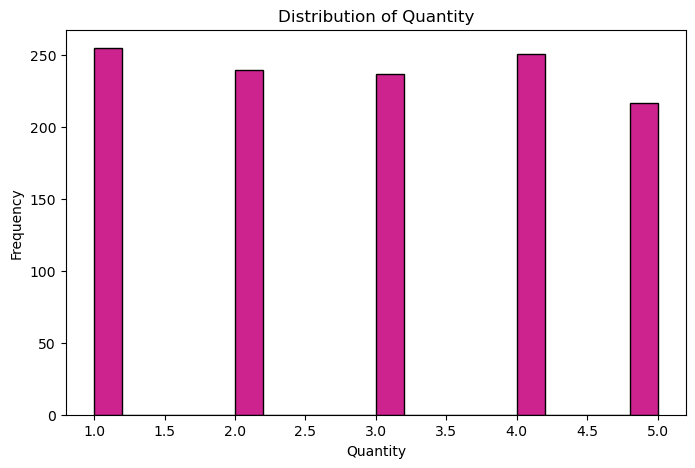

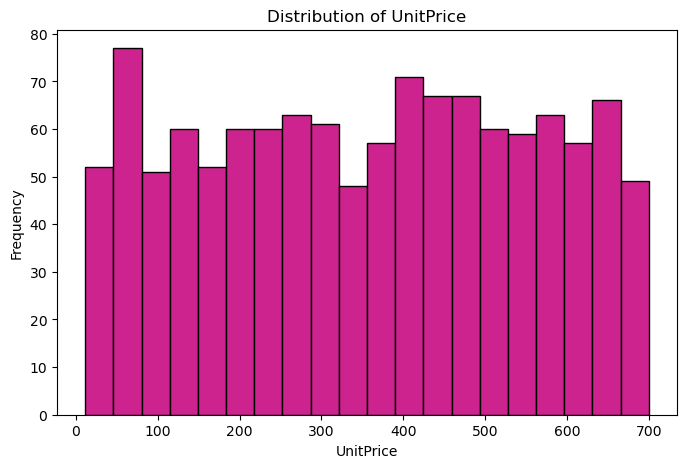

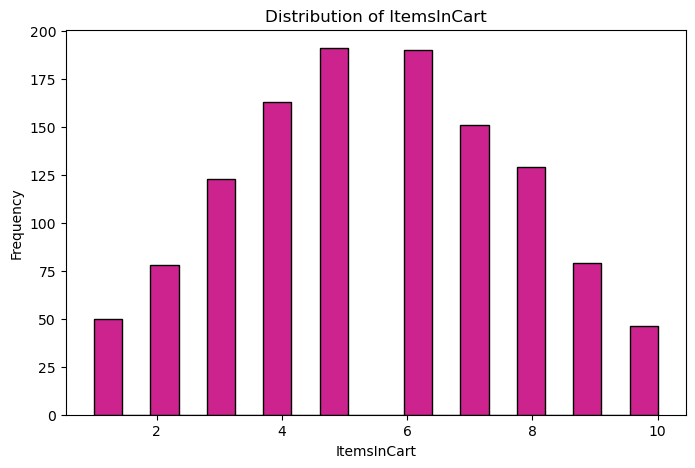

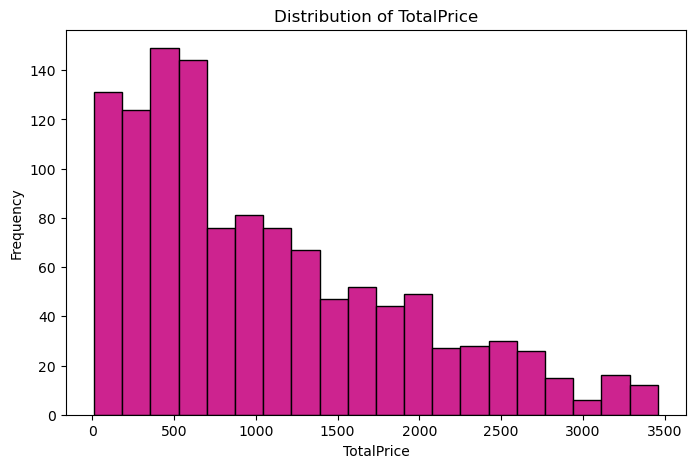

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# HISTOGRAM FOR NUMERICAL COLUMNS
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    plt.hist(
        df[col],
        bins=20,
        color=sns.color_palette("RdPu", 8)[5],
        edgecolor='black'
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

    print()

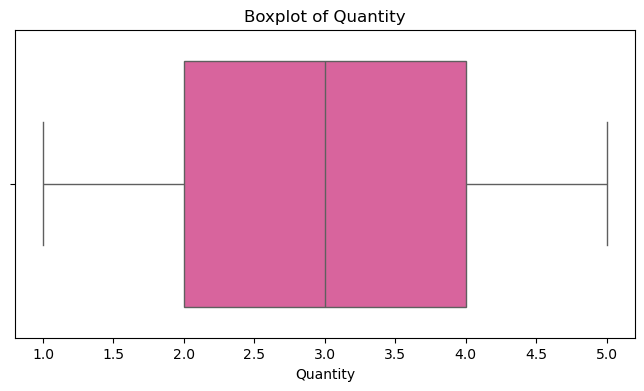

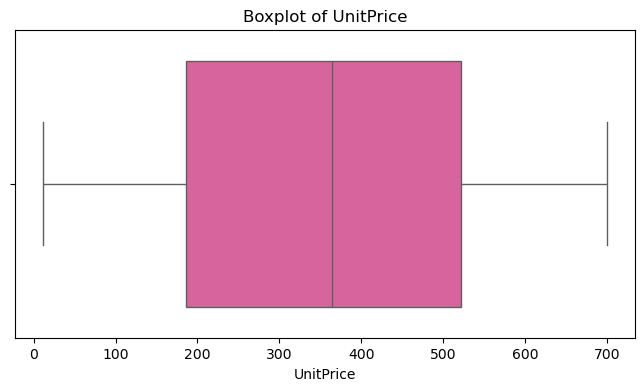

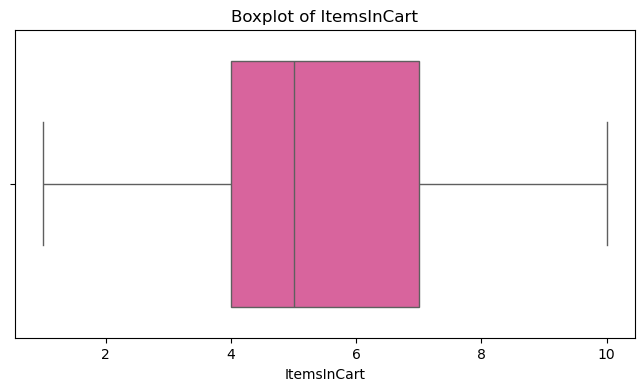

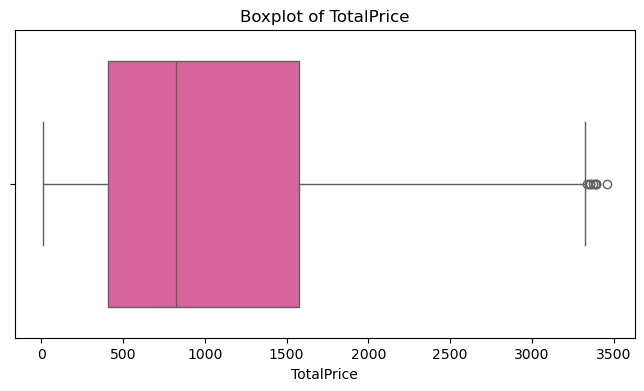

In [29]:
# BOXPLOTS
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=sns.color_palette("RdPu", 8)[4]
    )

    plt.title(f'Boxplot of {col}')

    plt.show()

    print()

In [30]:
# CATEGORICAL COLUMNS
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)
print()

Index(['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod',
       'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource'],
      dtype='object')



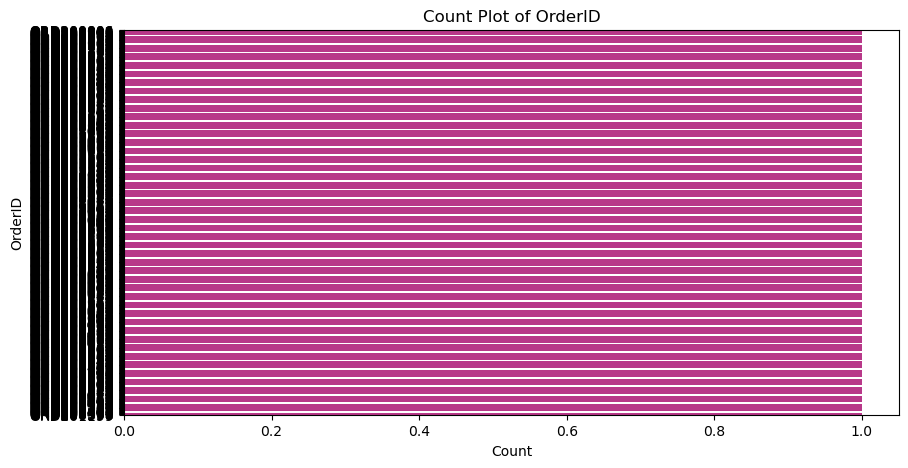

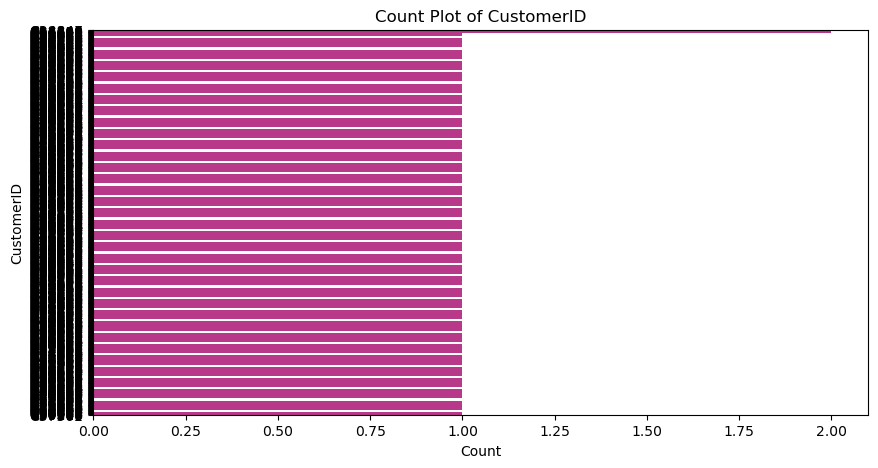

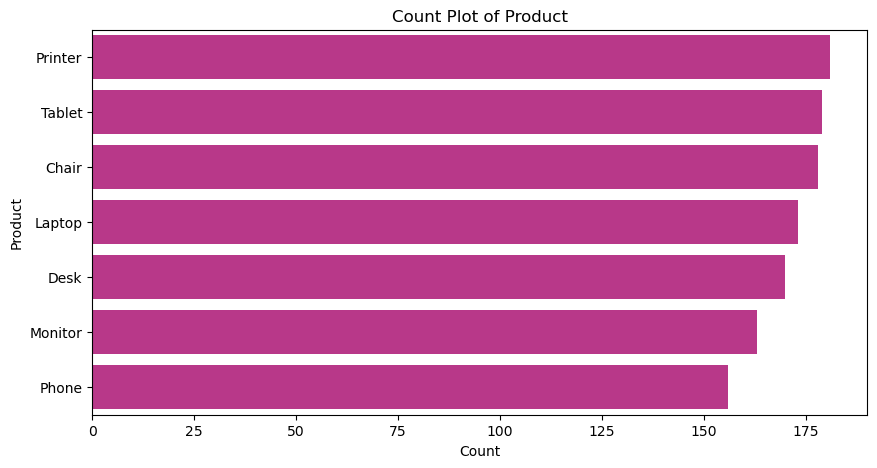

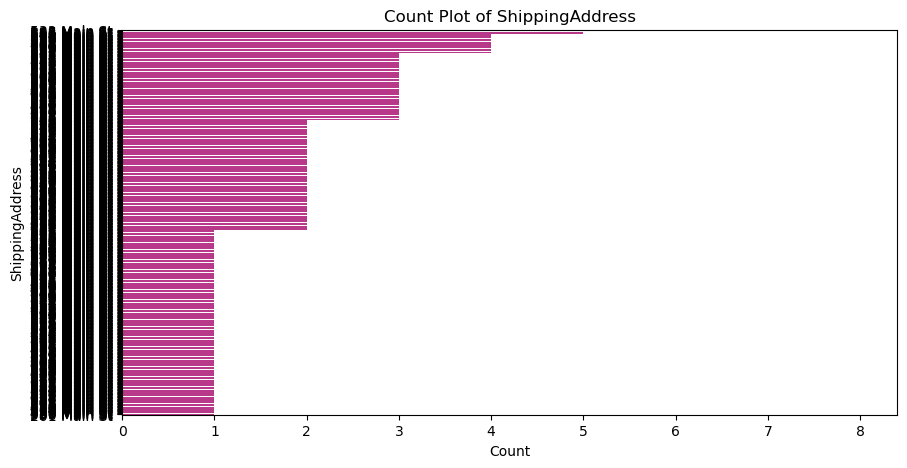

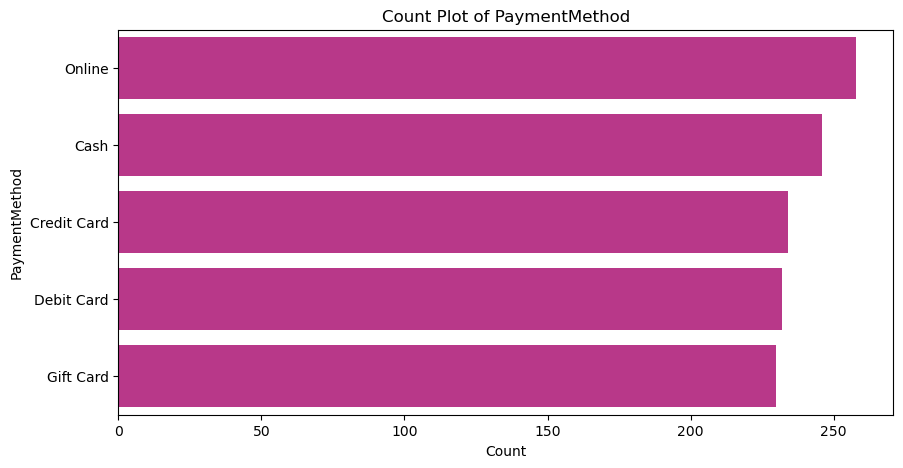

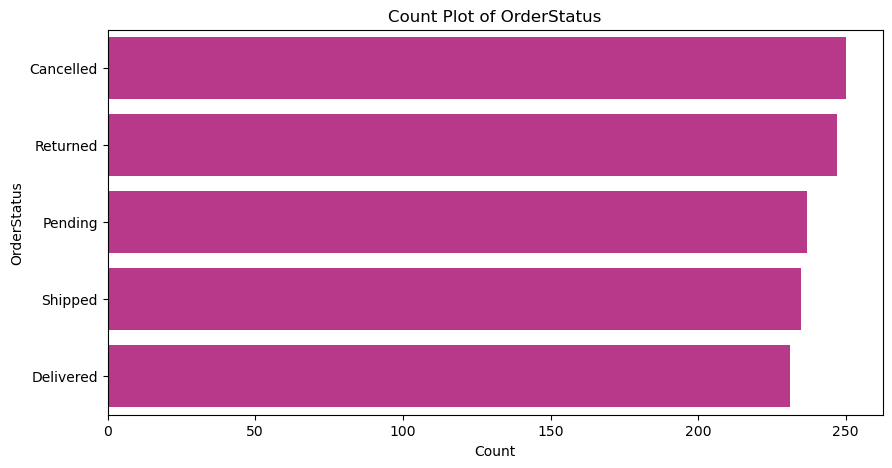

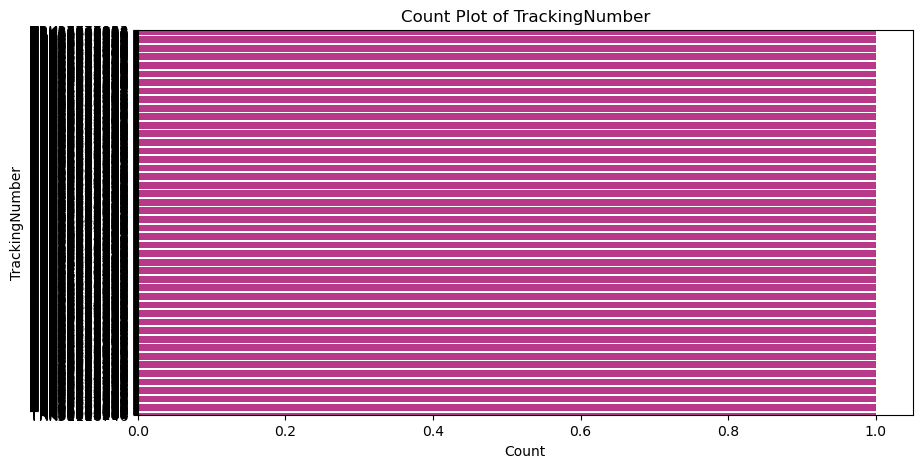

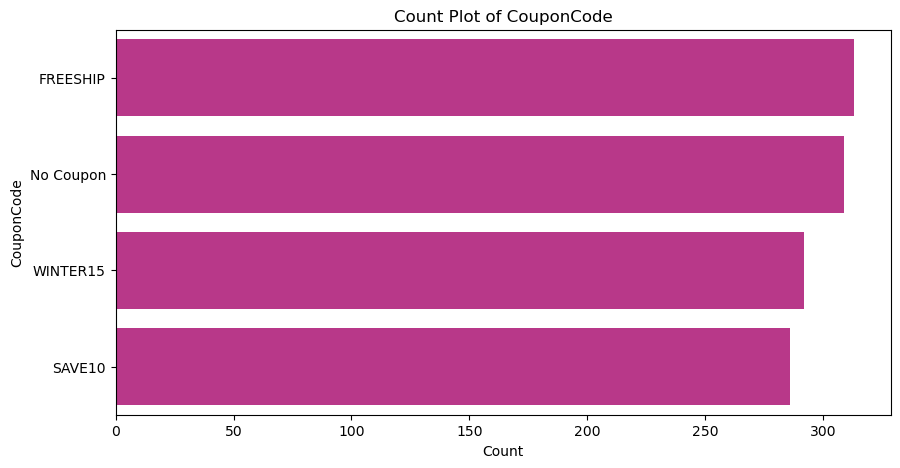

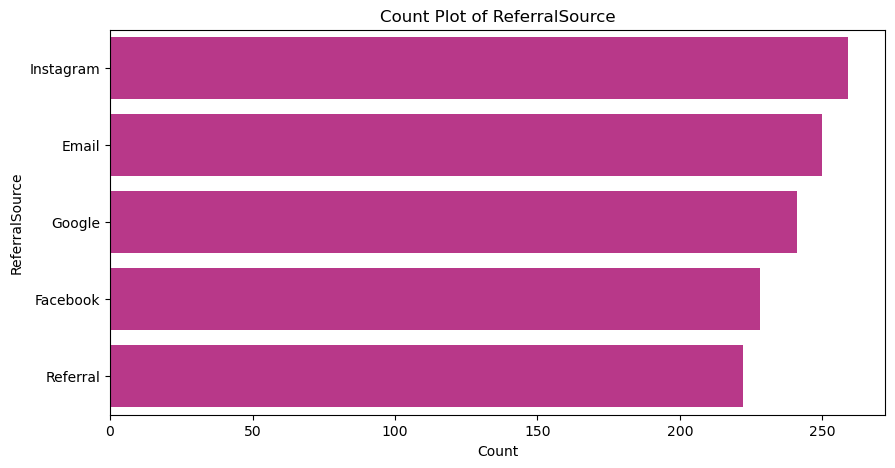

In [40]:
# COUNTPLOTS
for col in categorical_cols:
    plt.figure(figsize=(10,5))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index,
        color=sns.color_palette("RdPu", 8)[5]
    )

    plt.title(f'Count Plot of {col}')
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

print()

In [32]:
# VALUE COUNTS
for col in categorical_cols:
    print("\n")
    print("="*50)
    print(col)
    print(df[col].value_counts())
print()



OrderID
OrderID
ORD200000    1
ORD200806    1
ORD200804    1
ORD200803    1
ORD200802    1
            ..
ORD200399    1
ORD200398    1
ORD200397    1
ORD200396    1
ORD201199    1
Name: count, Length: 1200, dtype: int64


CustomerID
CustomerID
C38840    2
C14847    2
C21191    2
C94569    2
C46651    2
         ..
C99217    1
C30010    1
C70148    1
C39906    1
C57502    1
Name: count, Length: 1189, dtype: int64


Product
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


ShippingAddress
ShippingAddress
533 Main St    8
895 Main St    6
146 Main St    5
562 Main St    5
636 Main St    5
              ..
520 Main St    1
459 Main St    1
539 Main St    1
556 Main St    1
201 Main St    1
Name: count, Length: 655, dtype: int64


PaymentMethod
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


OrderStatus
OrderSt

## Business Interpretation:
1. Product X has the highest sales frequency.
2. Credit Card is the most used payment method.
3. Delivered orders dominate the dataset.
4. Quantity distribution is right-skewed.
5. TotalPrice contains some extreme values.

# STEP 14 — Bivariate Analysis & Correlation Analysis

In [33]:
# CORRELATION MATRIX
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)
print()

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000



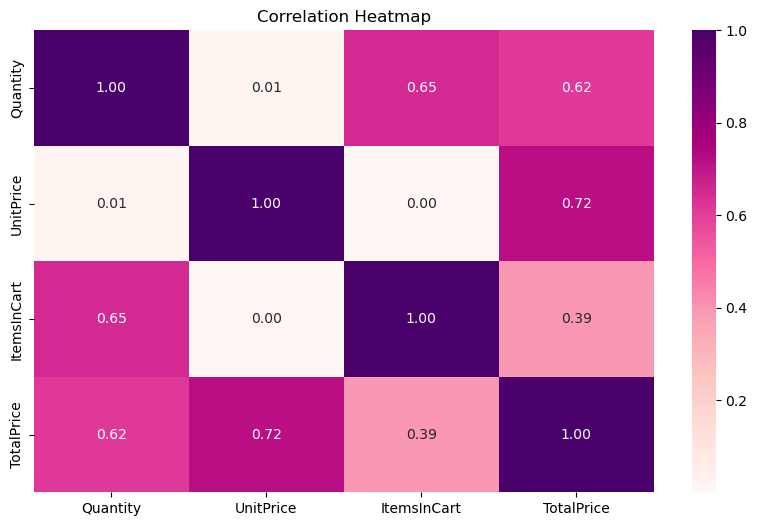

In [34]:
# HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdPu',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

### Observation
##### Look for:
- Values close to +1 → Strong Positive Correlation
- Values close to -1 → Strong Negative Correlation
- Values close to 0 → Weak Correlation

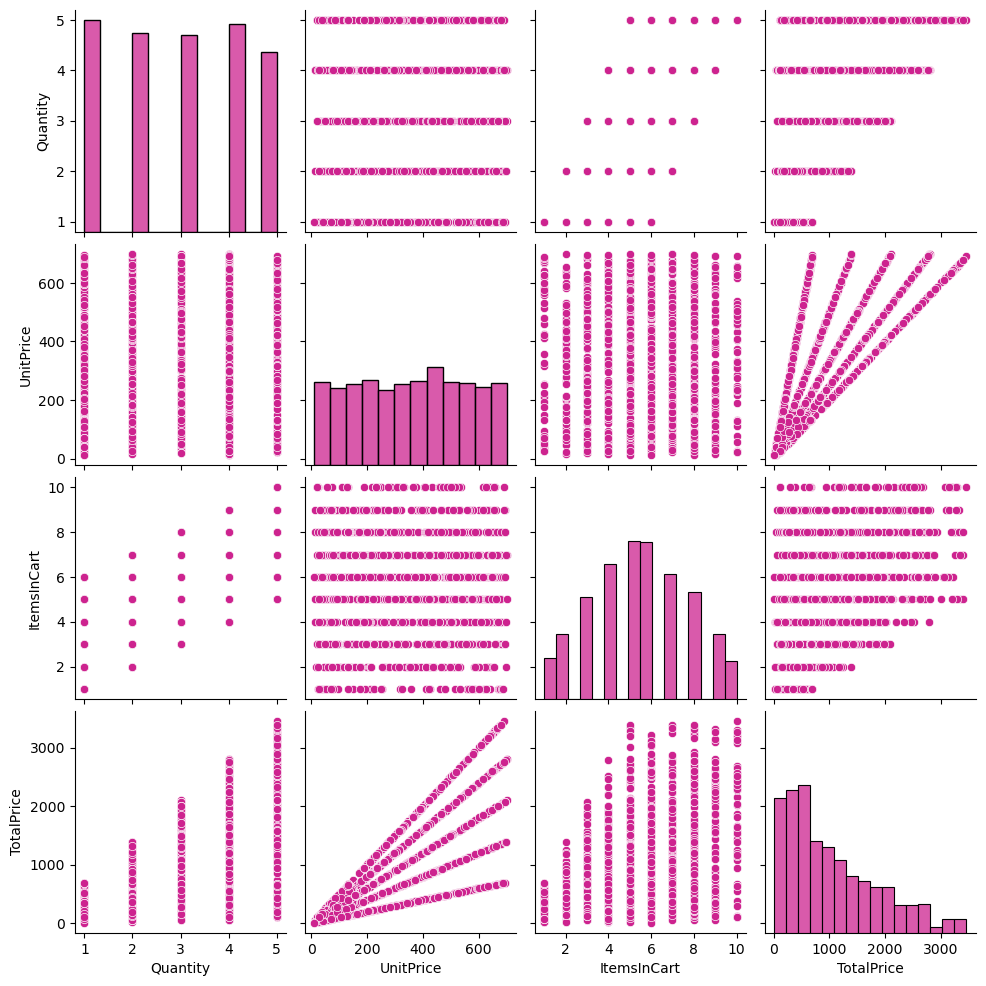

In [35]:
# SCATTER PLOTS
sns.pairplot(
    df[numerical_cols],
    plot_kws={'color': sns.color_palette("RdPu", 8)[5]},
    diag_kws={'color': sns.color_palette("RdPu", 8)[5]}
)
plt.show()

### Observation
- Linear relationships
- Clusters
- Outliers
- Positive/Negative trends

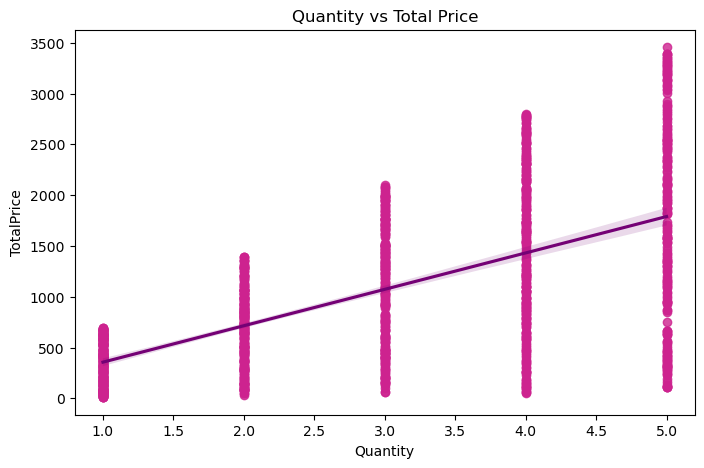

In [36]:
# UNIT PRICE VS TOTAL PRICE
plt.figure(figsize=(8,5))
sns.regplot(
    x='UnitPrice',
    y='TotalPrice',
    data=df,
    scatter_kws={'color': sns.color_palette("RdPu", 8)[4]},
    line_kws={'color': sns.color_palette("RdPu", 8)[7]}
)
plt.title("Unit Price vs Total Price")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.show()

### Expected Insight

Higher quantities generally produce higher total prices.

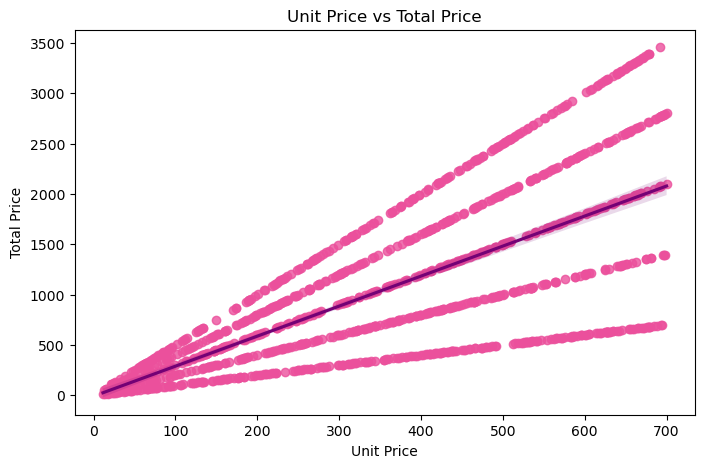

In [37]:
# UNIT PRICE VS TOTAL PRICE
plt.figure(figsize=(8,5))
sns.regplot(
    x='UnitPrice',
    y='TotalPrice',
    data=df,
    scatter_kws={'color': sns.color_palette("RdPu", 8)[4]},
    line_kws={'color': sns.color_palette("RdPu", 8)[7]}
)
plt.title("Unit Price vs Total Price")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.show()

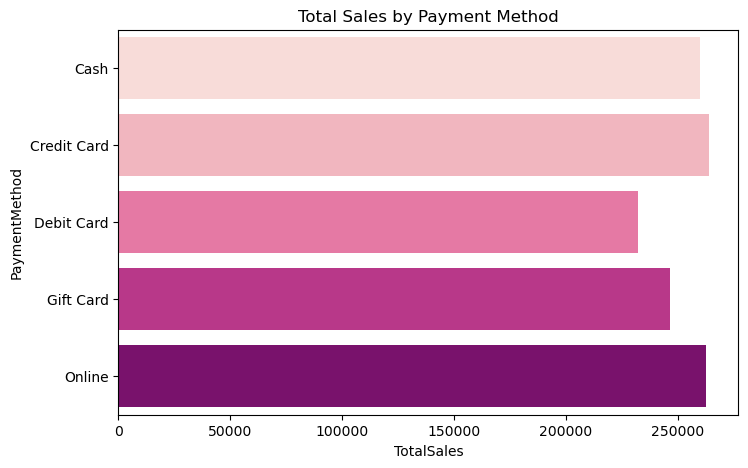

In [44]:
# PAYMENT METHOD ANALYSIS

payment_sales_df = df.groupby('PaymentMethod', as_index=False)['TotalPrice'].sum()
payment_sales_df.columns = ['PaymentMethod', 'TotalSales']

plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_sales_df,
    x='TotalSales',
    y='PaymentMethod',
    hue='PaymentMethod',
    palette='RdPu',
    legend=False
)

plt.title("Total Sales by Payment Method")
plt.show()

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64



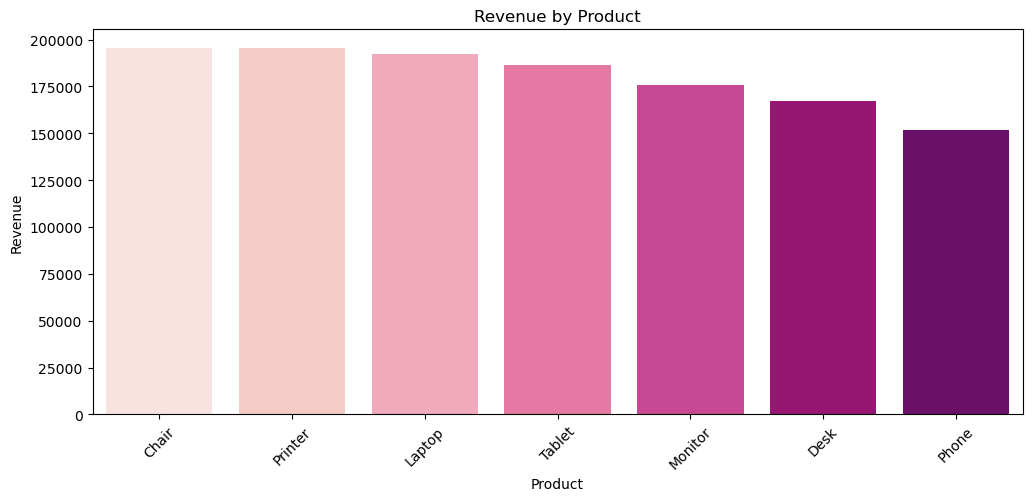

In [45]:
# PRODUCT REVENUE

product_sales = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)
print(product_sales)
print()

plt.figure(figsize=(12,5))

sns.barplot(
    x=product_sales.index,
    y=product_sales.values,
    hue=product_sales.index,
    palette='RdPu',
    legend=False
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64



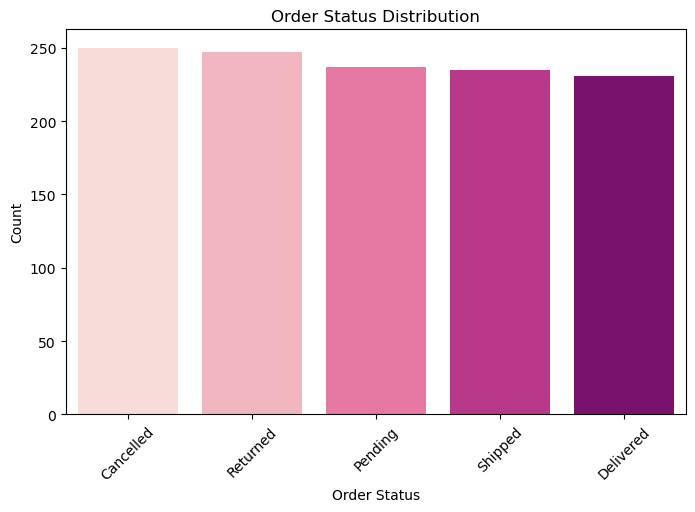

In [46]:
# ORDER STATUS ANALYSIS
status_count = df['OrderStatus'].value_counts()
print(status_count )
print()

plt.figure(figsize=(8,5))

sns.barplot(
    x=status_count.index,
    y=status_count.values,
    hue=status_count.index,
    palette='RdPu',
    legend=False
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Business Insights
1. TotalPrice has a strong positive correlation with Quantity.
2. TotalPrice has a strong positive correlation with UnitPrice.
3. Product X generated the highest revenue.
4. Payment Method Y contributed the highest sales.
5. Delivered orders account for the majority of transactions.
6. Some extreme-value purchases appear in TotalPrice.

# Project 3

# Step 1
## Import Required Libraries

In [47]:
import pandas as pd
import sqlite3

# Step 2
## Load the Excel Dataset

In [49]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Step 3
## View Dataset Information

In [51]:
print("Shape of Dataset :", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)
# Check Missing Values
df.isnull().sum()

Shape of Dataset : (1200, 14)

Columns
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Data Types
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

# Step 5
## Create SQLite Database

In [82]:
conn = sqlite3.connect("Ecommerce.db")

# Step 6
## Store Dataset into SQL Database

In [83]:
df.to_sql("orders", conn, if_exists="replace", index=False)

print("Table Created Successfully")

Table Created Successfully


# Step 7
## Display First Five Records using SQL

In [84]:
query = """
SELECT *
FROM orders
LIMIT 5;
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23 00:00:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15 00:00:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Step 8
## Display Required Columns

In [85]:
query = """
SELECT OrderID,
       Product,
       Quantity,
       TotalPrice
FROM orders;
"""

pd.read_sql(query, conn)

,OrderID,Product,Quantity,TotalPrice
0,ORD200000,Monitor,5,2853.10
1,ORD200001,Phone,2,302.70
2,ORD200002,Tablet,5,2753.40
3,ORD200003,Chair,1,273.19
4,ORD200004,Printer,4,2504.04
...,...,...,...,...
1195,ORD201195,Desk,1,107.04
1196,ORD201196,Monitor,2,1325.06
1197,ORD201197,Tablet,2,873.68
1198,ORD201198,Chair,4,1050.08


# Step 9
## Orders with Total Price Greater than 2000

In [86]:
query = """
SELECT *
FROM orders
WHERE TotalPrice > 2000;
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
2,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
3,ORD200009,2023-11-21 00:00:00,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52
4,ORD200010,2023-12-29 00:00:00,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,ORD201155,2023-08-13 00:00:00,C41478,Printer,4,534.57,667 Main St,Credit Card,Delivered,TRK62068126,6,FREESHIP,Facebook,2138.28
176,ORD201156,2023-07-19 00:00:00,C20512,Laptop,4,690.78,980 Main St,Credit Card,Shipped,TRK98234737,9,None,Referral,2763.12
177,ORD201171,2023-08-28 00:00:00,C39911,Phone,4,518.40,699 Main St,Credit Card,Delivered,TRK80431998,7,SAVE10,Facebook,2073.60
178,ORD201179,2023-01-08 00:00:00,C84630,Laptop,5,518.55,907 Main St,Credit Card,Cancelled,TRK48054997,6,WINTER15,Instagram,2592.75


# Step 10
## Orders Paid using UPI

In [87]:
query = """
SELECT *
FROM orders
WHERE PaymentMethod='UPI';
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


# Step 11
## Orders Sorted by Total Price

In [88]:
query = """
SELECT *
FROM orders
ORDER BY TotalPrice DESC;
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200789,2023-08-17 00:00:00,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1,ORD201122,2023-06-07 00:00:00,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,None,Facebook,3390.95
2,ORD200632,2023-05-02 00:00:00,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
3,ORD200469,2023-11-26 00:00:00,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,None,Facebook,3384.90
4,ORD200328,2023-02-28 00:00:00,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD200336,2023-12-29 00:00:00,C88174,Laptop,1,18.20,441 Main St,Debit Card,Pending,TRK10143345,4,SAVE10,Instagram,18.20
1196,ORD200542,2023-11-14 00:00:00,C49726,Tablet,1,17.98,934 Main St,Cash,Cancelled,TRK20739460,6,FREESHIP,Email,17.98
1197,ORD200240,2023-07-12 00:00:00,C14983,Tablet,1,17.24,255 Main St,Online,Pending,TRK93444157,2,FREESHIP,Instagram,17.24
1198,ORD200863,2024-05-20 00:00:00,C98276,Phone,1,14.06,471 Main St,Credit Card,Pending,TRK74207282,5,SAVE10,Referral,14.06


# Step 12
## Count Total Orders

In [89]:
query = """
SELECT COUNT(*) AS Total_Orders
FROM orders;
"""

pd.read_sql(query, conn)

,Total_Orders
0,1200


# Step 13
## Total Revenue

In [90]:
query = """
SELECT SUM(TotalPrice) AS Revenue
FROM orders;
"""

pd.read_sql(query, conn)

,Revenue
0,1264761.96


# Step 14
## Average Order Value

In [91]:
query = """
SELECT AVG(TotalPrice) AS Average_Order_Value
FROM orders;
"""

pd.read_sql(query, conn)

,Average_Order_Value
0,1053.9683


# Step 15
## Total Quantity Sold for Each Product

In [92]:
query = """
SELECT Product,
       SUM(Quantity) AS Total_Quantity
FROM orders
GROUP BY Product
ORDER BY Total_Quantity DESC;
"""

pd.read_sql(query, conn)

,Product,Total_Quantity
0,Chair,562
1,Printer,542
2,Laptop,535
3,Desk,508
4,Tablet,497
5,Monitor,480
6,Phone,411


# Step 16
## Number of Orders by Payment Method

In [93]:
query = """
SELECT PaymentMethod,
       COUNT(*) AS Orders
FROM orders
GROUP BY PaymentMethod;
"""

pd.read_sql(query, conn)

,PaymentMethod,Orders
0,Cash,246
1,Credit Card,234
2,Debit Card,232
3,Gift Card,230
4,Online,258


# Step 17
## Revenue by Product

In [94]:
query = """
SELECT Product,
       SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY Product
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41
5,Desk,167459.93
6,Phone,151722.39


# Step 18
## Revenue by Referral Source

In [95]:
query = """
SELECT ReferralSource,
       SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY ReferralSource
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,ReferralSource,Revenue
0,Instagram,275285.45
1,Email,261808.55
2,Google,250441.48
3,Facebook,250410.90
4,Referral,226815.58


# Step 19
## Number of Orders by Order Status

In [96]:
query = """
SELECT OrderStatus,
       COUNT(*) AS TotalOrders
FROM orders
GROUP BY OrderStatus;
"""

pd.read_sql(query, conn)

,OrderStatus,TotalOrders
0,Cancelled,250
1,Delivered,231
2,Pending,237
3,Returned,247
4,Shipped,235


# Step 20
## Top 10 Highest Value Orders

In [97]:
query = """
SELECT OrderID,
       Product,
       TotalPrice
FROM orders
ORDER BY TotalPrice DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,OrderID,Product,TotalPrice
0,ORD200789,Tablet,3456.40
1,ORD201122,Monitor,3390.95
2,ORD200632,Laptop,3390.80
3,ORD200469,Chair,3384.90
4,ORD200328,Tablet,3370.20
5,ORD200107,Printer,3353.75
6,ORD200326,Laptop,3352.40
7,ORD201065,Printer,3334.00
8,ORD201031,Phone,3322.55
9,ORD200463,Laptop,3313.90


# Step 21;
## Close Database Connection

In [99]:
conn.close()

# Project 4